# Project 8 -- [Katie] [Baumgartner]

TA Help: N/A

Collaboration: N/A

Internet Resources: N/A

ChatGPT, Gemini, Claude, etc: N/A

## Question 1

In [1]:
orders <- read.csv("/anvil/projects/tdm/data/restaurant/orders.csv")

In [2]:
orders$created_at <- as.Date(orders$created_at)

In [3]:
library(lubridate)


Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union




In [4]:
orders$num_day_of_the_week <- wday(orders$created_at)

In [5]:
orders$day_of_the_week <- wday(orders$created_at, label=TRUE)

In [6]:
table(orders$num_day_of_the_week)


    1     2     3     4     5     6     7 
18651 19676 22003 20619 22210 15906 16238 

In [7]:
table(orders$day_of_the_week)


  Sun   Mon   Tue   Wed   Thu   Fri   Sat 
18651 19676 22003 20619 22210 15906 16238 

In [8]:
table(orders$num_day_of_the_week, orders$day_of_the_week)

   
      Sun   Mon   Tue   Wed   Thu   Fri   Sat
  1 18651     0     0     0     0     0     0
  2     0 19676     0     0     0     0     0
  3     0     0 22003     0     0     0     0
  4     0     0     0 20619     0     0     0
  5     0     0     0     0 22210     0     0
  6     0     0     0     0     0 15906     0
  7     0     0     0     0     0     0 16238

In [9]:
wday(1:7, label = TRUE)

[1] Sun Mon Tue Wed Thu Fri Sat
Levels: Sun < Mon < Tue < Wed < Thu < Fri < Sat

DELIVERABLES
1.1) Makes working with dates and times easier by providing simple functions.
1.2) Above code
1.3) POSIXlt

## Question 2

In [10]:
orders$month <- month(orders$created_at, label=TRUE)

In [11]:
orders$year <- year(orders$created_at)

In [12]:
table(orders$month)


  Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec 
17825 23683     0     0     1 10120 10175  8933  6609 19893 18249 19815 

In [13]:
table(orders$year)


 2019  2020 
93795 41508 

In [14]:
monthly_items <- tapply(orders$item_count, orders$month, sum, na.rm = TRUE)
monthly_items

Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec 
40410 51197    NA    NA     0 27839 27296 23853 16098 31527 43102 47479

In [15]:
subset(orders, month == "Mar")
subset(orders, is.na(month))

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"


akeed_order_id,customer_id,item_count,grand_total,payment_mode,promo_code,vendor_discount_amount,promo_code_discount_percentage,is_favorite,is_rated,...,delivery_date,vendor_id,created_at,LOCATION_NUMBER,LOCATION_TYPE,CID.X.LOC_NUM.X.VENDOR,num_day_of_the_week,day_of_the_week,month,year
<dbl>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<chr>,...,<chr>,<int>,<date>,<int>,<chr>,<chr>,<dbl>,<ord>,<ord>,<dbl>


Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"


akeed_order_id,customer_id,item_count,grand_total,payment_mode,promo_code,vendor_discount_amount,promo_code_discount_percentage,is_favorite,is_rated,...,delivery_date,vendor_id,created_at,LOCATION_NUMBER,LOCATION_TYPE,CID.X.LOC_NUM.X.VENDOR,num_day_of_the_week,day_of_the_week,month,year
<dbl>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<chr>,...,<chr>,<int>,<date>,<int>,<chr>,<chr>,<dbl>,<ord>,<ord>,<dbl>


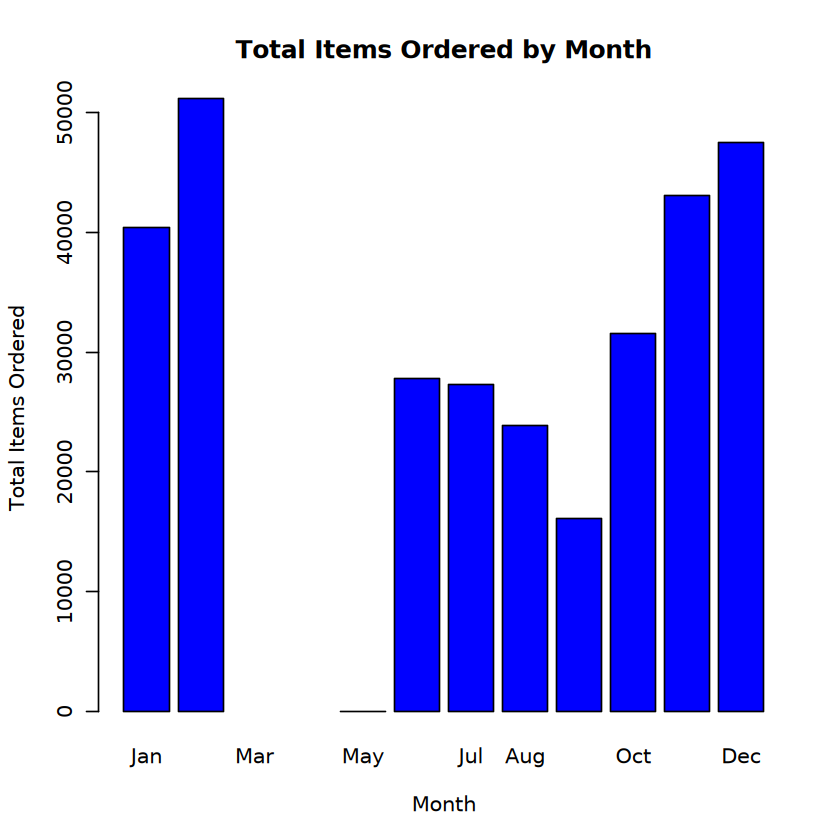

In [16]:
barplot(monthly_items, main = "Total Items Ordered by Month", xlab = "Month", ylab = "Total Items Ordered", col = "blue")

In [17]:
year_month_items <- tapply(orders$item_count, list(orders$year, orders$month), sum, na.rm = TRUE)
year_month_items

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2019,NA,NA,NA,NA,0,27839,27296,23853,16098,31527,43102,47479
2020,40410,51197,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


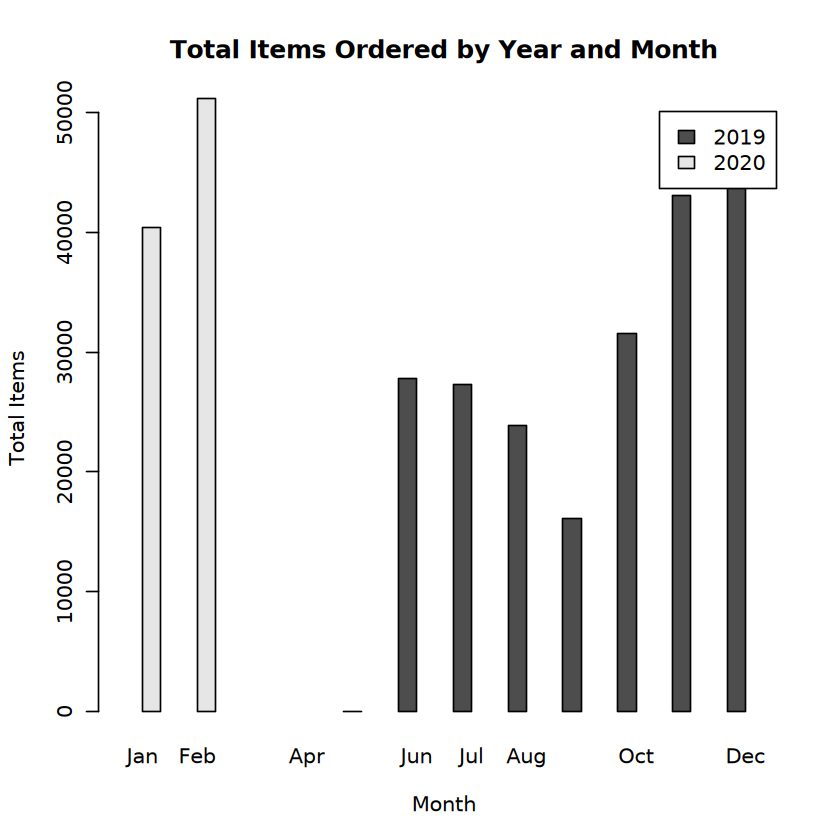

In [18]:
barplot(year_month_items, beside = TRUE, legend = TRUE, main = "Total Items Ordered by Year and Month", xlab = "Month", ylab = "Total Items")

In [19]:
table(orders$month)


  Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec 
17825 23683     0     0     1 10120 10175  8933  6609 19893 18249 19815 

DELIVERABLES
2.1) June-Feb
2.2) Their were orders in those months, but their item_count was NA; tapply cannot sum actual numbers just NAs
2.3) Code above

## Question 3

In [20]:
flights <- read.csv('/anvil/projects/tdm/data/flights/subset/1997.csv')

In [21]:
library(lubridate)
flights$full_dates <- ymd(paste(flights$Year, flights$Month, flights$DayofMonth, sep = "-"))

In [22]:
flights$DepTime[flights$DepTime == 2400] <- 0

In [23]:
flights$depHour <- floor(flights$DepTime / 100)

In [24]:
flights$depMinute <- flights$DepTime %% 100

In [25]:
flights$date_times <- make_datetime(year = flights$Year, month = flights$Month, day = flights$DayofMonth, hour = flights$depHour, min = flights$depMinute)

DELIVERABLES
3.1) Above code
3.2) Above code
3.3) Year-Month-Day; converts into a Date object (YYYY-MM-DD)

## Question 4

In [26]:
bostonDF <- flights[flights$Origin == "BOS", ]

In [27]:
boston_distance <- tapply(bostonDF$Distance, bostonDF$Month, mean, na.rm = TRUE)

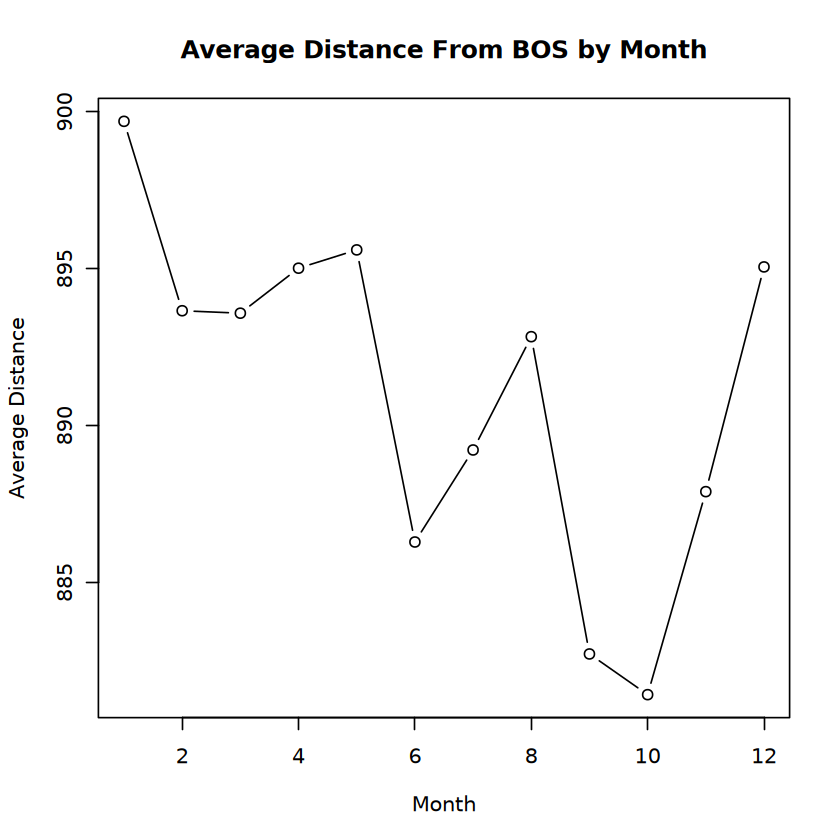

In [28]:
plot(boston_distance, type = 'b', main = "Average Distance From BOS by Month", xlab = "Month", ylab = "Average Distance")

In [29]:
phoenixDF <- flights[flights$Origin == "PHX", ]
phoenix_distance <- tapply(phoenixDF$Distance, phoenixDF$Month, mean, na.rm = TRUE)

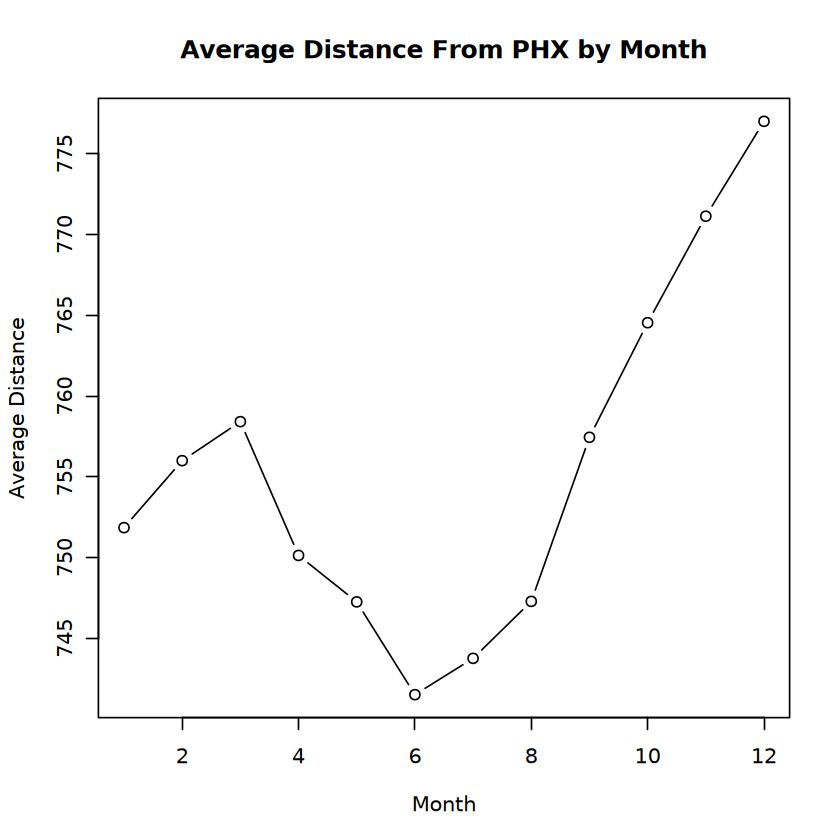

In [30]:
plot(phoenix_distance, type='b', main='Average Distance From PHX by Month', xlab='Month', ylab='Average Distance')

In [31]:
chicagoDF <- flights[flights$Origin == "MDW", ]
chicago_distance <- tapply(chicagoDF$Distance, chicagoDF$Month, mean, na.rm = TRUE)

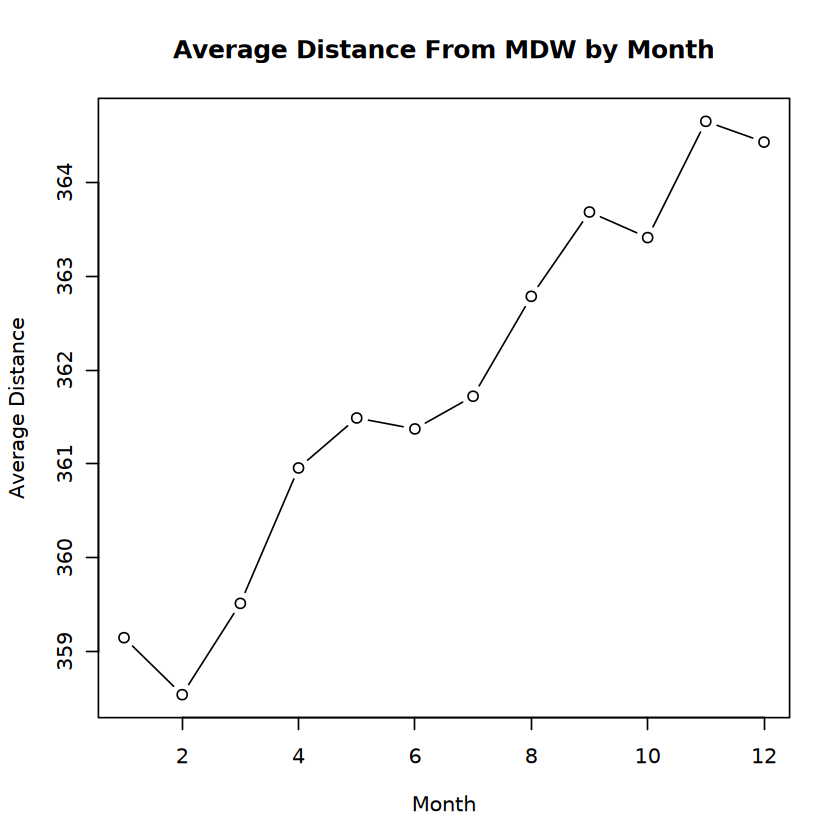

In [32]:
plot(chicago_distance, type='b', main='Average Distance From MDW by Month', xlab='Month', ylab='Average Distance')

In [33]:
seattleDF <- flights[flights$Origin == "SEA", ]
seattle_distance <- tapply(seattleDF$Distance, seattleDF$Month, mean, na.rm = TRUE)

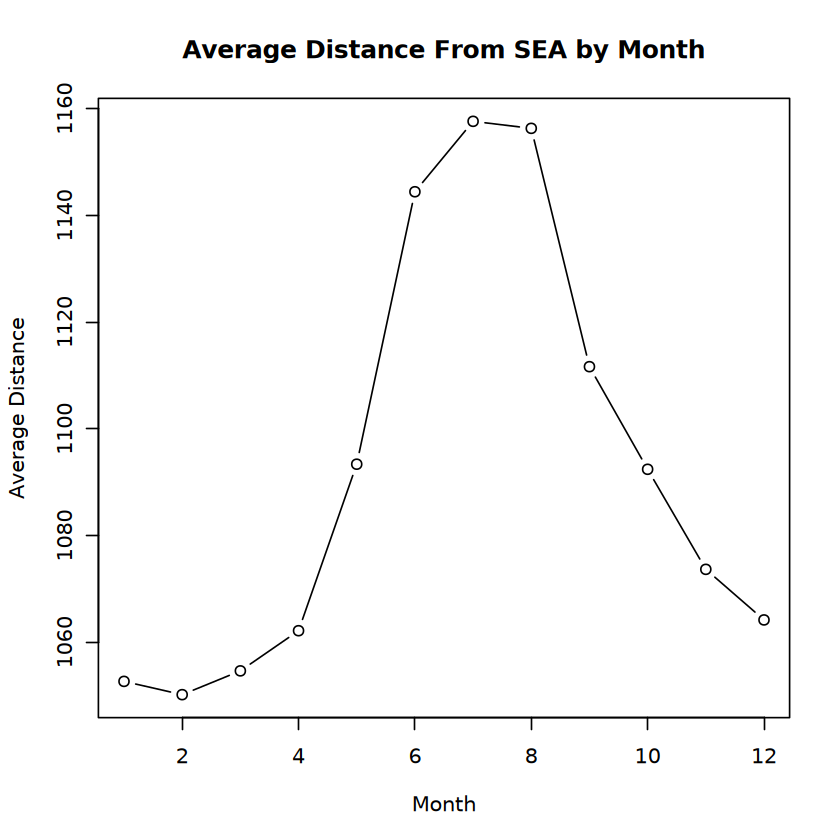

In [34]:
plot(seattle_distance, type='b', main='Average Distance From SEA by Month', xlab='Month', ylab='Average Distance')

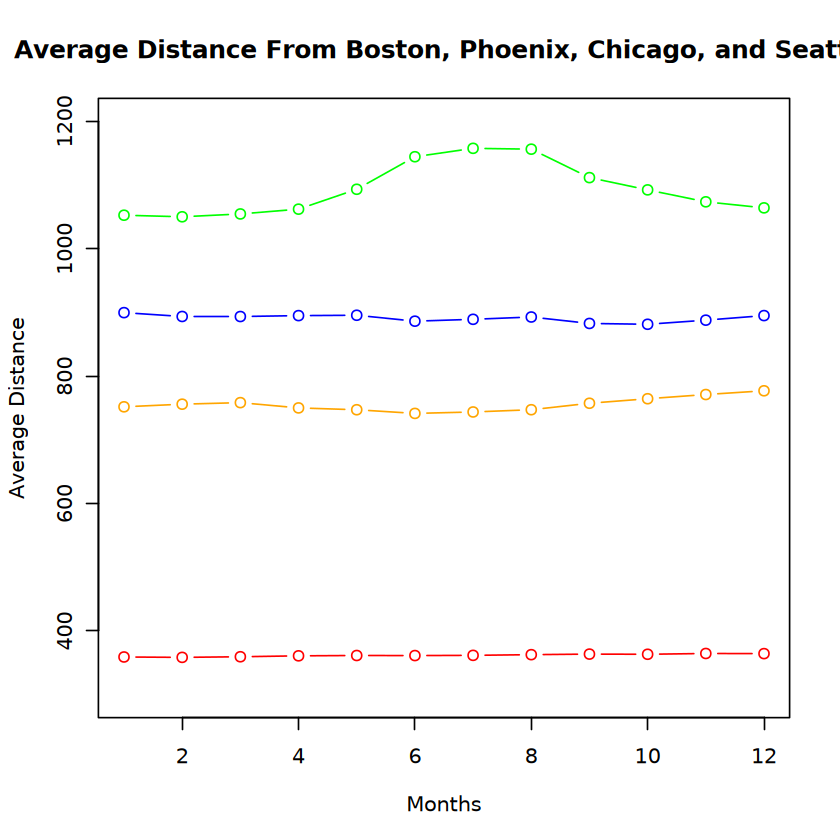

In [35]:
plot(boston_distance,
    type='b',
    col='blue',
     ylim=c(300,
            1200),
     main='Average Distance From Boston, Phoenix, Chicago, and Seattle',
     xlab='Months',
     ylab='Average Distance'
    )
lines(phoenix_distance,
      type='b',
    col='orange'
      )
lines(chicago_distance,
      type='b',
    col='red'
      )
lines(seattle_distance,
      type='b',
    col='green'
      )

DELIVERABLES
4.1) Seattle, Boston, Phoenix, Chicago
4.2) Above code
4.3) The differences are due to geographic location. Depending on an airports location, a flight may be longer or shorter.

## Question 5

In [36]:
boston_total <- tapply(bostonDF$Distance, bostonDF$Month, sum, na.rm = TRUE)

In [37]:
phoenix_total <- tapply(phoenixDF$Distance, phoenixDF$Month, sum, na.rm = TRUE)

In [38]:
chicago_total <- tapply(chicagoDF$Distance, chicagoDF$Month, sum, na.rm = TRUE)

In [39]:
seattle_total <- tapply(seattleDF$Distance, seattleDF$Month, sum, na.rm = TRUE)

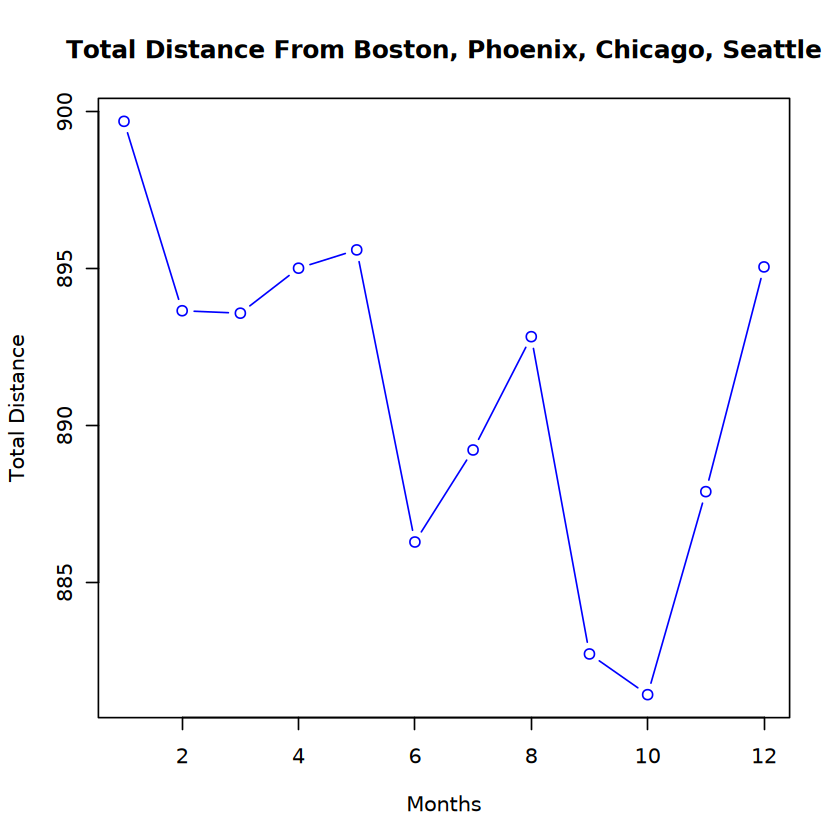

In [40]:
plot(boston_distance,
    type='b',
    col='blue',
     main='Total Distance From Boston, Phoenix, Chicago, Seattle',
     xlab='Months',
     ylab='Total Distance'
    )
lines(phoenix_distance,
      type='b',
    col='orange'
      )
lines(chicago_distance,
      type='b',
    col='red'
      )
lines(seattle_distance,
      type='b',
    col='green'
      )

In [41]:
all_max <- max(boston_total, phoenix_total, chicago_total, seattle_total)
all_min <- min(boston_total, phoenix_total, chicago_total, seattle_total)

In [42]:
y_min <- all_min * 0.95
y_max <- all_max * 1.05

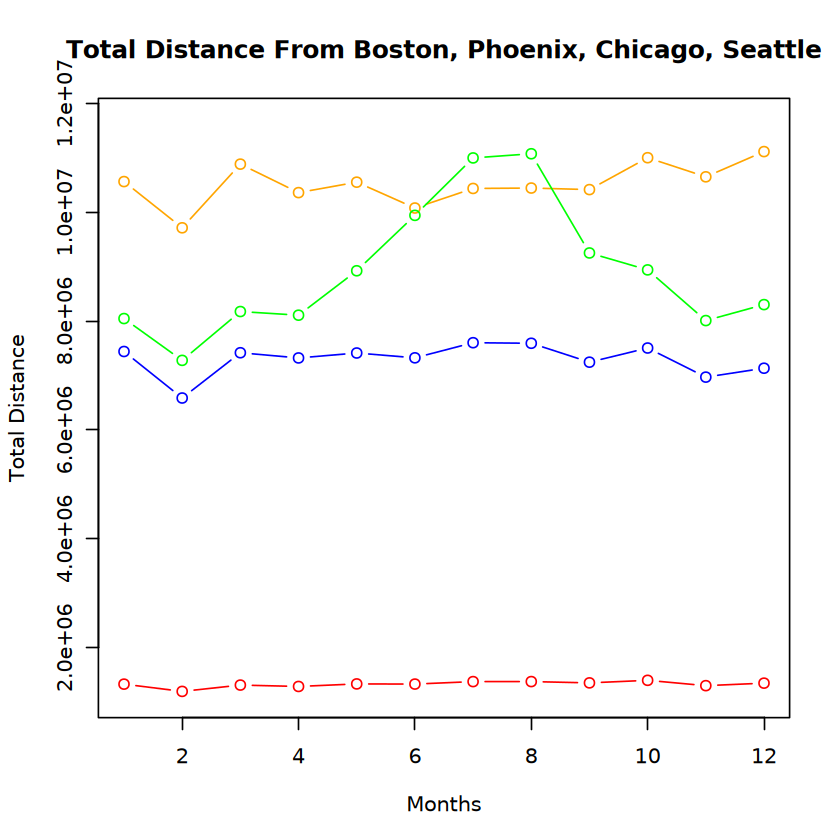

In [43]:
plot(boston_total,
     type='b',
     col='blue',
     ylim=c(y_min, y_max),
     main='Total Distance From Boston, Phoenix, Chicago, Seattle',
     xlab='Months',
     ylab='Total Distance')

lines(phoenix_total,
      type='b',
      col='orange')

lines(chicago_total,
      type='b',
      col='red')

lines(seattle_total,
      type='b',
      col='green')

DELIVERABLES
5.1) Above code
5.2) Above code
5.3) Above code

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
